Image Information:
Dimensions: (411, 251, 3)
Data Type: uint8
Pixel Value Range: [28, 190]


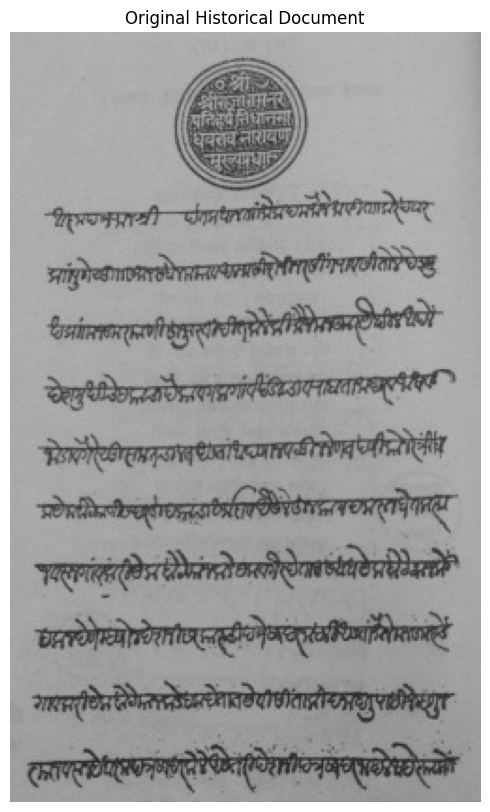

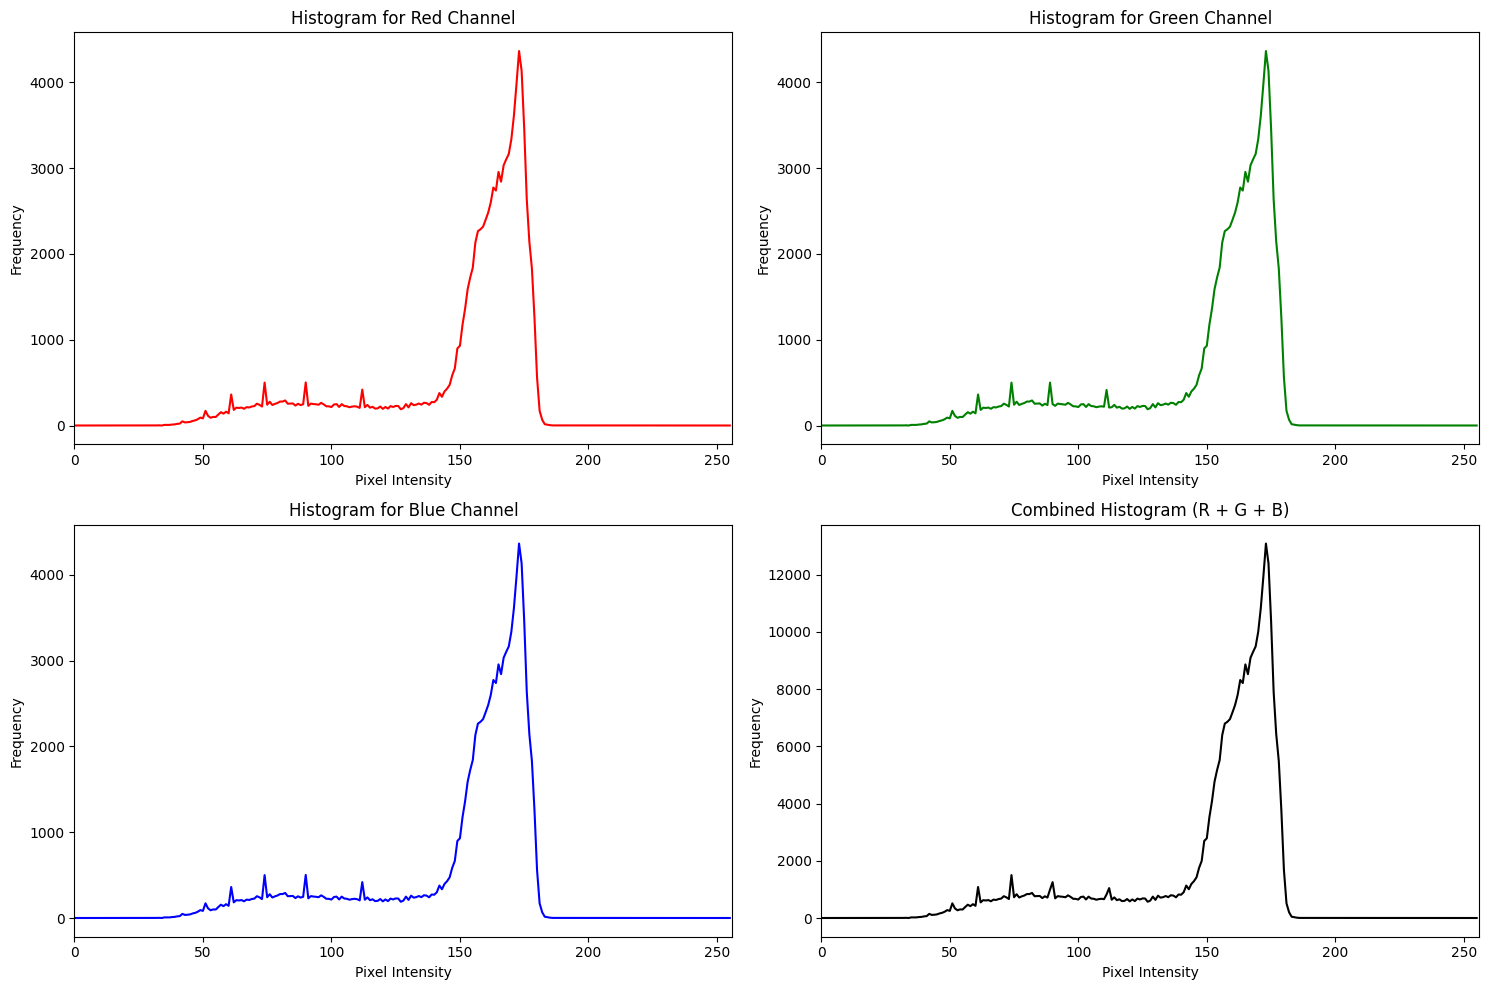

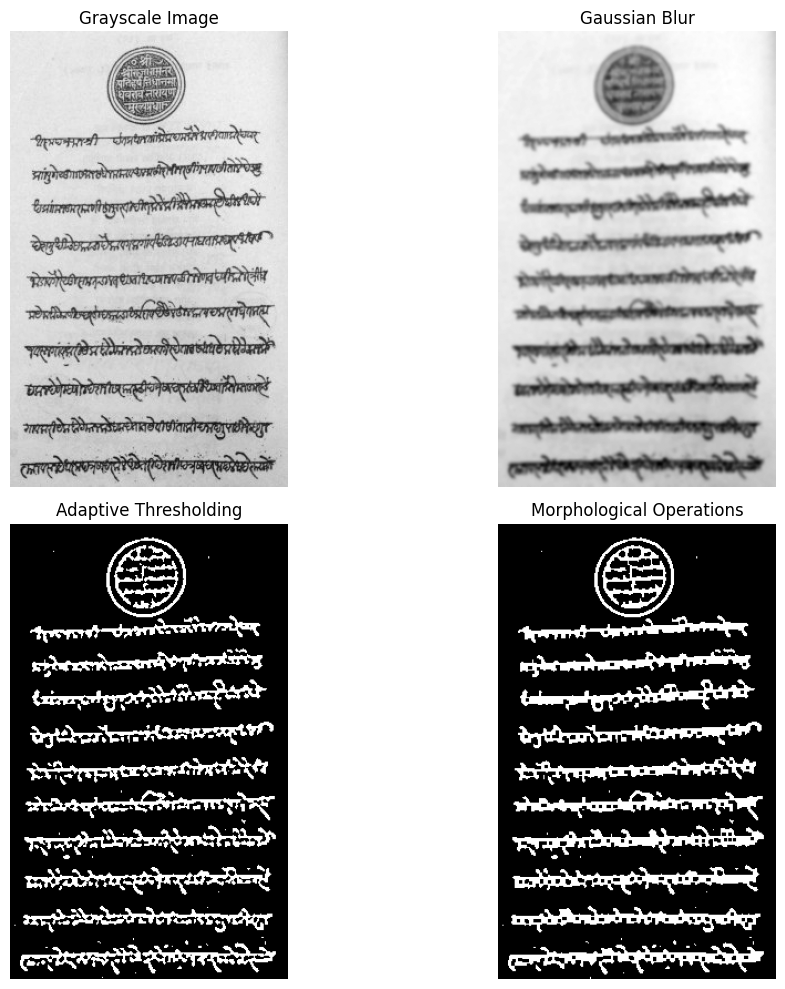

In [395]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_document_image(image_path):
    """
    Load image and provide detailed information
    
    Args:
        image_path (str): Path to input image
    
    Returns:
        numpy.ndarray: Loaded RGB image
    """
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Could not load image")
    
    # Convert to RGB (OpenCV loads images in BGR by default)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Image information
    print("Image Information:")
    print(f"Dimensions: {image.shape}")
    print(f"Data Type: {image.dtype}")
    print(f"Pixel Value Range: [{np.min(image)}, {np.max(image)}]")
    
    # Display original image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.title('Original Historical Document')
    plt.axis('off')
    plt.show()
    
    return image_rgb

def plot_histograms(image):
    """
    Plot histograms for Red, Green, Blue channels and combined histogram.
    
    Args:
        image (numpy.ndarray): RGB image
    
    Returns:
        None
    """
    # Split the image into R, G, B channels
    r_channel, g_channel, b_channel = cv2.split(image)
    
    # Calculate histograms for each channel
    r_hist = cv2.calcHist([r_channel], [0], None, [256], [0, 256])
    g_hist = cv2.calcHist([g_channel], [0], None, [256], [0, 256])
    b_hist = cv2.calcHist([b_channel], [0], None, [256], [0, 256])
    
    # Calculate the combined histogram (all channels)
    combined_hist = r_hist + g_hist + b_hist
    
    # Plot all histograms
    plt.figure(figsize=(15, 10))
    
    # Plot Red channel histogram
    plt.subplot(2, 2, 1)
    plt.plot(r_hist, color='red')
    plt.title('Histogram for Red Channel')
    plt.xlim(0, 256)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    
    # Plot Green channel histogram
    plt.subplot(2, 2, 2)
    plt.plot(g_hist, color='green')
    plt.title('Histogram for Green Channel')
    plt.xlim(0, 256)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    
    # Plot Blue channel histogram
    plt.subplot(2, 2, 3)
    plt.plot(b_hist, color='blue')
    plt.title('Histogram for Blue Channel')
    plt.xlim(0, 256)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    
    # Plot Combined histogram (R + G + B)
    plt.subplot(2, 2, 4)
    plt.plot(combined_hist, color='black')
    plt.title('Combined Histogram (R + G + B)')
    plt.xlim(0, 256)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    
    # Display all histograms
    plt.tight_layout()
    plt.show()


import cv2
import numpy as np

import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    # 2. Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    axs[0, 0].imshow(gray, cmap='gray')
    axs[0, 0].set_title('Grayscale Image')
    axs[0, 0].axis('off')
    
    # 3. Noise reduction using Gaussian blur
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    axs[0, 1].imshow(blurred, cmap='gray')
    axs[0, 1].set_title('Gaussian Blur')
    axs[0, 1].axis('off')

    # 4. Binarization using adaptive thresholding
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 7, 2
    )
    axs[1, 0].imshow(thresh, cmap='gray')
    axs[1, 0].set_title('Adaptive Thresholding')
    axs[1, 0].axis('off')
    
    # 5. Morphological operations to clean up the binary image
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=1)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    eroded = cv2.erode(dilated, kernel, iterations=1)
    axs[1, 1].imshow(eroded, cmap='gray')
    axs[1, 1].set_title('Morphological Operations')
    axs[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return eroded



def detect_lines_with_bboxes(image, preprocessed):
    """
    Detect text lines and draw bounding boxes
    """
    # Find contours
    contours, _ = cv2.findContours(
        preprocessed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    
    # Sort contours by y-coordinate
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])
    
    # Create copy for visualization
    result = image.copy()
    line_images = []
    
    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        
        # Filter out small contours
        if  w > 10 and h > 10  and y >80:  # Adjust these thresholds as needed
            # Draw rectangle
            cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)
            
            # Crop line
            line = image[y:y+h, x:x+w]
            line_images.append(line)
            
            # Save individual line
            cv2.imwrite(f'line_{i+1}.png', line)
    

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title('Bounding Box Detection')
    plt.axis('off')
    return result, line_images



# Path to the historical document image
image_path = './../Dataset/historical-doc.png'

# Load the image and explore it
image_rgb = load_document_image(image_path)

# Plot the histogram of the image
plot_histograms(image_rgb)

preprocessed_image = preprocess_image(image_rgb)



    

## Image Preprocessing Steps for Text Line Detection

The following preprocessing steps were applied to the image to enhance text detection and structure preservation.

### 1. **Grayscale Conversion**
Grayscale conversion is a standard first step to simplify the image and focus on the luminance information rather than color. This makes subsequent processing simpler.

### 2. **Gaussian Blur**
The Gaussian blur helps reduce noise and high-frequency details, which can interfere with text line detection. The 7x7 kernel size was chosen to provide a moderate level of smoothing without overly blurring the text.

### 3. **Adaptive Thresholding**
Adaptive thresholding was used for binarization as it can handle variable lighting conditions in the historical document. The Gaussian adaptive method and the specific parameters (block size 7, constant 2) were selected to effectively separate text from the background.

### 4. **Morphological Operations (Dilation and Erosion)**
Morphological operations like dilation and erosion were applied to clean up the binary image further. The 3x3 kernel size and a single iteration were found to be sufficient for filling small gaps and removing noise without distorting the text structure.



### **Preprocessing Results:**
These preprocessing steps enhanced the image by:

- Normalizing the grayscale intensity distribution
- Smoothing out noise and high-frequency variations
- Clearly separating text from the background
- Cleaning up the binary representation of text

The resulting preprocessed image should be well-suited for subsequent text line detection, as the text regions are now more distinct, and the overall document structure is preserved. The techniques strike a balance between enhancing the text while avoiding over-processing that could degrade important information.


### 3.2.1 Rectangular Bounding Box Detection

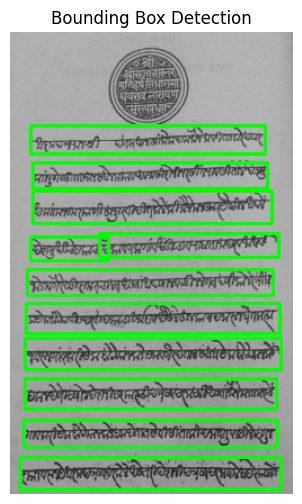

In [396]:

bounding_boxes = detect_lines_with_bboxes(image_rgb, preprocessed_image)



## 3.2.2 Line Segmentation within the Circular Region

1


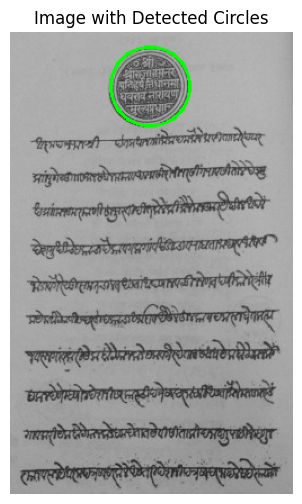

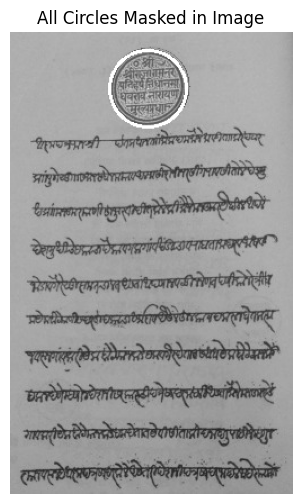

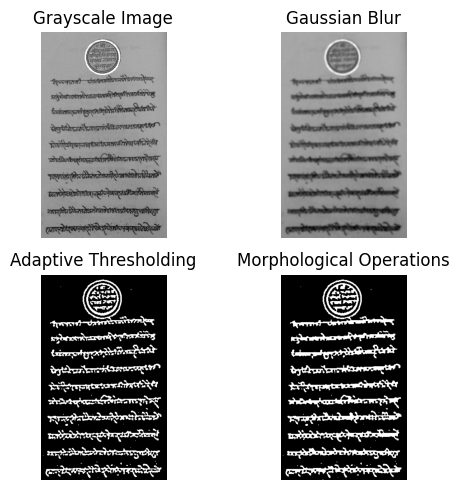

In [397]:


import cv2
import numpy as np
import matplotlib.pyplot as plt


def preprocess_image(image):

    fig, axs = plt.subplots(2, 2, figsize=(6, 5))
    # 2. Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    axs[0, 0].imshow(gray, cmap='gray')
    axs[0, 0].set_title('Grayscale Image')
    axs[0, 0].axis('off')
    
    # 3. Noise reduction using Gaussian blur
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    axs[0, 1].imshow(blurred, cmap='gray')
    axs[0, 1].set_title('Gaussian Blur')
    axs[0, 1].axis('off')

    # 4. Binarization using adaptive thresholding
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 7, 2
    )
    axs[1, 0].imshow(thresh, cmap='gray')
    axs[1, 0].set_title('Adaptive Thresholding')
    axs[1, 0].axis('off')
    
    # 5. Morphological operations to clean up the binary image
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=1)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    eroded = cv2.erode(dilated, kernel, iterations=1)
    axs[1, 1].imshow(eroded, cmap='gray')
    axs[1, 1].set_title('Morphological Operations')
    axs[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return eroded

def segment_lines_in_seal(image, preprocessed):
    """
    Detect circles in the preprocessed image, visualize the result with circles, 
    and return the image with inverted pixels inside the circles (without the circles).
    """
    # Detect circles using Hough Circle Transform in the preprocessed image
    circles = cv2.HoughCircles(
        preprocessed, cv2.HOUGH_GRADIENT, 1, 100,
        param1=50, param2=30, minRadius=30, maxRadius=40
    )
    
    result = image.copy()  # Copy of the original image for visualization
    result_no_circles = image.copy()  # This will store the final result with inverted pixels
    
    if circles is not None:
        circles = np.uint16(np.around(circles))  # Round the circle values
        
        for i in circles[0, :]:
            # Visualize the circle on the image
            cv2.circle(result, (i[0], i[1]), i[2], (0, 255, 0), 2)  # Draw circle
            
            # Create a mask for the circle
            mask = np.zeros_like(preprocessed)  # Create an empty mask
            cv2.circle(mask, (i[0], i[1]), i[2], 255, -1)  # Draw a filled circle on the mask
            
            # Invert the pixels inside the circle in the result_no_circles image
            result_no_circles[mask == 255] = 255 - result_no_circles[mask == 255]
    
    # Visualize the result with the circles on top
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))  # Show the image with circles
    plt.title('Image with Detected Circles')
    plt.axis('off')

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(result_no_circles, cv2.COLOR_BGR2RGB))  # Show the image with circles
    plt.title('Image with Inverted Pixels Inside Circles')
    plt.axis('off')
    
    # Return the image with the inverted pixels inside circles but no circles
    return result_no_circles

import cv2
import numpy as np

def detect_lines_with_bboxes(image, preprocessed):
    """
    Detect text lines and draw bounding boxes.
    """
    # Find contours
    contours, _ = cv2.findContours(preprocessed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort contours by y-coordinate
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])

    # Create copy for visualization
    result = image.copy()
    line_images = []

    # Detect text within the circular seal
    seal_contours = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if  w < 30 or h < 30:
            if 5 < x < 350 and  y < 90:  # Adjust the range to target the seal region
                seal_contours.append(contour)
                cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 2)  # Blue bounding boxes for seal text
                line = image[y:y+h, x:x+w]
                line_images.append(line)
                # cv2.imwrite(f'circle_line_{len(line_images)}.png', line)

    # Visualize the result with the circles on top
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))  # Show the image with circles
    plt.title('Image with Detected Circles')
    plt.axis('off')

    return result, line_images


def mark_all_circles_in_image(result_image):
    """
    Detect all circles in the image and mark them with a visible outline.
    Args:
        result_image (numpy array): Input image where circles are detected.
    Returns:
        marked_image (numpy array): Image with all detected circles marked.
        circles_params (list of tuples): List of (x, y, radius) for all detected circles.
    """
    # Convert the image to grayscale for circle detection
    gray = cv2.cvtColor(result_image, cv2.COLOR_BGR2GRAY)
    
    # Apply GaussianBlur to reduce noise and improve circle detection
    # blurred = cv2.GaussianBlur(gray, (9, 9), 2)
    
    # Detect circles using Hough Circle Transform
    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=20,
        param1=50,
        param2=20,
        minRadius=28,
        maxRadius=35
    )
    print(len(circles))
    if circles is not None:
        # Round circle parameters to integers
        circles = np.round(circles[0, :]).astype("int")
        
        # Copy the input image for modification
        modified_image = result_image.copy()
        
        # Process each detected circle
        for (x, y, radius) in circles:
            # Draw the circle's boundary in white
            cv2.circle(modified_image, (x, y), radius, (255, 255, 255), 2)  # White circle boundary (thickness=2)
            
            # Mark the circle center pixel as 250 in all channels
            if 0 <= y < modified_image.shape[0] and 0 <= x < modified_image.shape[1]:  # Check bounds
                modified_image[y, x] = [250, 250, 250]  # Set pixel to [250, 250, 250] for all channels
        
        # Return the modified image and the list of detected circles
        return modified_image, [(x, y, radius) for (x, y, radius) in circles]
    
    else:
        raise ValueError("No circles were detected in the image.")




# Assuming `image_rgb` is the original image and `preprocessed_image` is the preprocessed image for circle detection
# Example usage:
result_image = segment_lines_in_seal(image_rgb, preprocessed_image)

masked_image, circles_params = mark_all_circles_in_image(result_image)
plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
plt.title("All Circles Masked in Image")
plt.axis("off")
plt.show()
up_masked_img= masked_image.copy()
preprocessed_image = preprocess_image(masked_image)




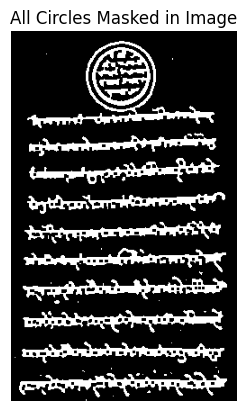

(411, 251, 3)


In [398]:

def mark_circles_with_white_boundary_repeated(result_image):

    # Check if the input image is grayscale (single channel) or color (multi-channel)
    is_grayscale = len(result_image.shape) == 2
    
    # Create a copy of the input image for marking
    if is_grayscale:
        modified_image = cv2.cvtColor(result_image, cv2.COLOR_GRAY2BGR)  # Convert to color for marking
    else:
        modified_image = result_image.copy()
    
    all_circles = []

    
    # Detect circles using Hough Circle Transform
    circles = cv2.HoughCircles(
        result_image,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=20,  # Reduced to detect nearby circles
        param1=50,
        param2=20,  # Lowered for higher sensitivity
        minRadius=28,
        maxRadius=35
    )
    
    
    if circles is not None:
        # Round circle parameters to integers
        circles = np.round(circles[0, :]).astype("int")
        
        # Store detected circles
        for (x, y, radius) in circles:
            all_circles.append((x, y, radius))
                 # Mark the circle center pixel as 250 (single or all channels)
            if is_grayscale:
                modified_image[y, x] = 200  # Single channel, set to white
            else:
                modified_image[y, x] = [250, 250, 250]  # Multi-channel, set to white
        
        # Mask detected circles to focus on remaining areas
        for (x, y, radius) in circles[:11]:
            cv2.circle(result_image, (x, y), radius, 0, -1)  # Black out the circle region in the blurred image
   

    return modified_image, all_circles

masked_image, circles_params = mark_circles_with_white_boundary_repeated(preprocessed_image)
plt.imshow((masked_image))
plt.title("All Circles Masked in Image")
plt.axis("off")
plt.show()

print(masked_image.shape)



# remove circle make it black, then run above bounding baox algo

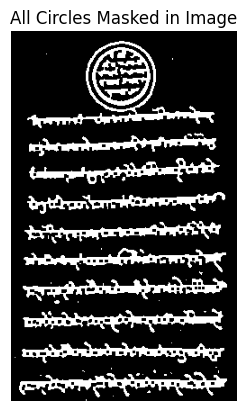

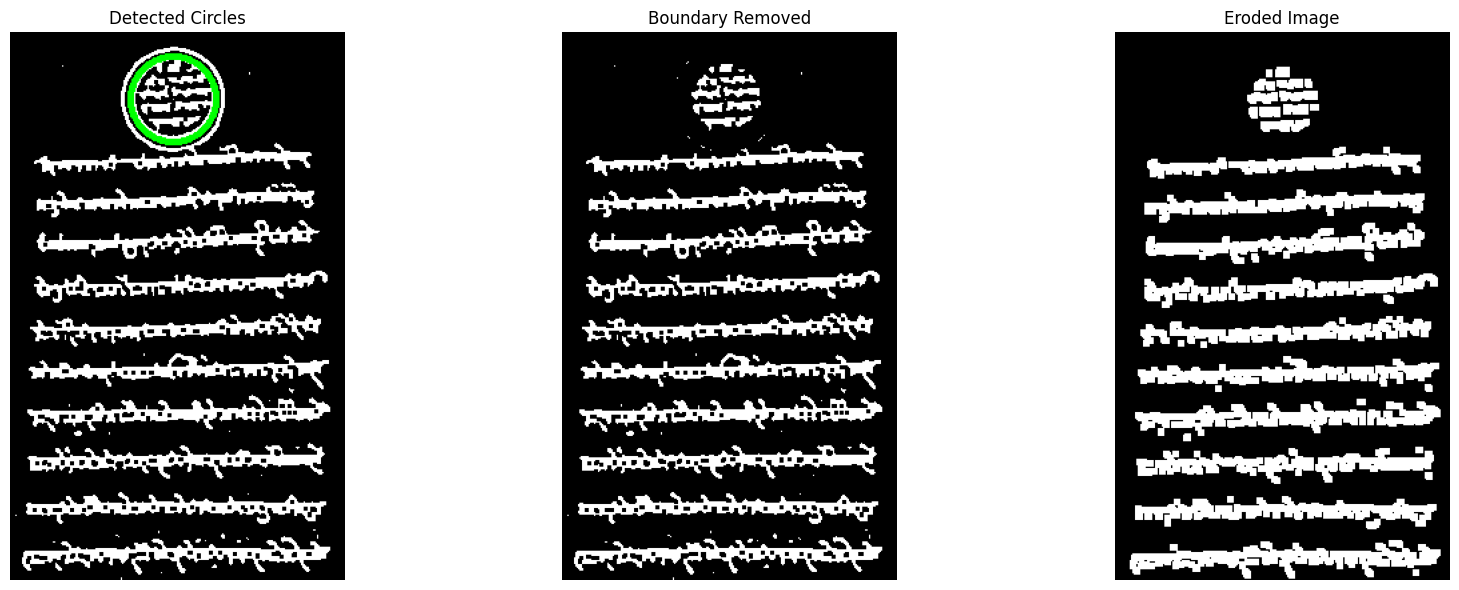

In [399]:
masked_image_copy = np.copy(masked_image)


plt.imshow((masked_image_copy))
plt.title("All Circles Masked in Image")
plt.axis("off")
plt.show()


# Assuming masked_image_copy is your binary image with white circles
original_image = np.copy(masked_image_copy)  # Store the original image for comparison

# Convert the image to grayscale if it's not already (though it's binary in this case, we still use the grayscale conversion)
gray_image = cv2.cvtColor(masked_image_copy, cv2.COLOR_BGR2GRAY)

# Apply Hough Circle Transform to detect circles
circles = cv2.HoughCircles(
    gray_image, 
    cv2.HOUGH_GRADIENT, dp=1.2, minDist=20,
    param1=50, param2=30, minRadius=28, maxRadius=35
)

# If circles are found, convert them to integer values and process the image
if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    
    # Iterate through each detected circle
    for (x, y, r) in circles:
        # Draw the detected circle on the original image (boundary only)
        cv2.circle(original_image, (x, y), r, (0, 255, 0), 4)
        
        # Remove the 10-pixel-wide boundary (perimeter) of the circle, leaving the inside intact
        mask = np.zeros_like(masked_image_copy)  # Create a black mask
        
        cv2.circle(mask, (x, y), r+3, (255, 255, 255), 8)   # Outer boundary
        cv2.circle(mask, (x, y), r - 1, (255, 255, 255), 8)   # Inner boundary, filled with black to remove pixels

        # Apply the mask to remove the 10-pixel-wide boundary
        masked_image_copy[mask == 255] = 0  # Set the pixels around the circle boundary to black

# Create a 1x3 plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image with circles drawn
axes[0].imshow(original_image)
axes[0].set_title("Detected Circles")
axes[0].axis("off")

# Image after the 10-pixel-wide boundary is removed
axes[1].imshow(masked_image_copy)
axes[1].set_title("Boundary Removed")
axes[1].axis("off")

# Eroded image
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
eroded = cv2.erode(masked_image_copy, kernel, iterations=2)
eroded = cv2.dilate(eroded, kernel, iterations=4)
axes[2].imshow(cv2.cvtColor(eroded, cv2.COLOR_BGR2RGB))
axes[2].set_title("Eroded Image")
axes[2].axis("off")

# Adjust layout and show
plt.tight_layout()
plt.show()

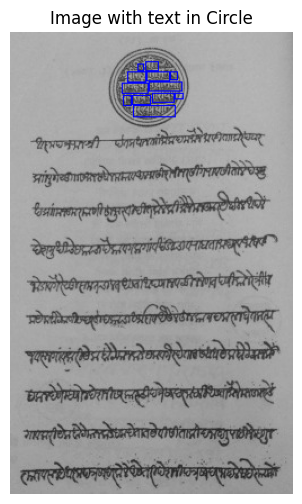

In [400]:
def detect_lines_with_bboxes(image, preprocessed):
    """
    Detect text lines and draw bounding boxes.
    """
    # Convert to grayscale if necessary
    preprocessed_gray = cv2.cvtColor(preprocessed, cv2.COLOR_BGR2GRAY)
    
    # Find contours
    contours, _ = cv2.findContours(preprocessed_gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort contours by y-coordinate
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])

    # Create copy for visualization
    result = image.copy()
    line_images = []

    # Detect text within the circular seal
    seal_contours = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if  w >2 or h >2:
            if 5 < x < 350 and  y < 85:  # Adjust the range to target the seal region
                seal_contours.append(contour)
                cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 1)  # Blue bounding boxes for seal text
                line = image[y:y+h, x:x+w]
                line_images.append(line)
                # cv2.imwrite(f'circle_line_{len(line_images)}.png', line)

    # Visualize the result with the circles on top
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))  # Show the image with circles
    plt.title('Image with text in Circle')
    plt.axis('off')

    return result, line_images



bounding_boxes,_ = detect_lines_with_bboxes(image_rgb, eroded)



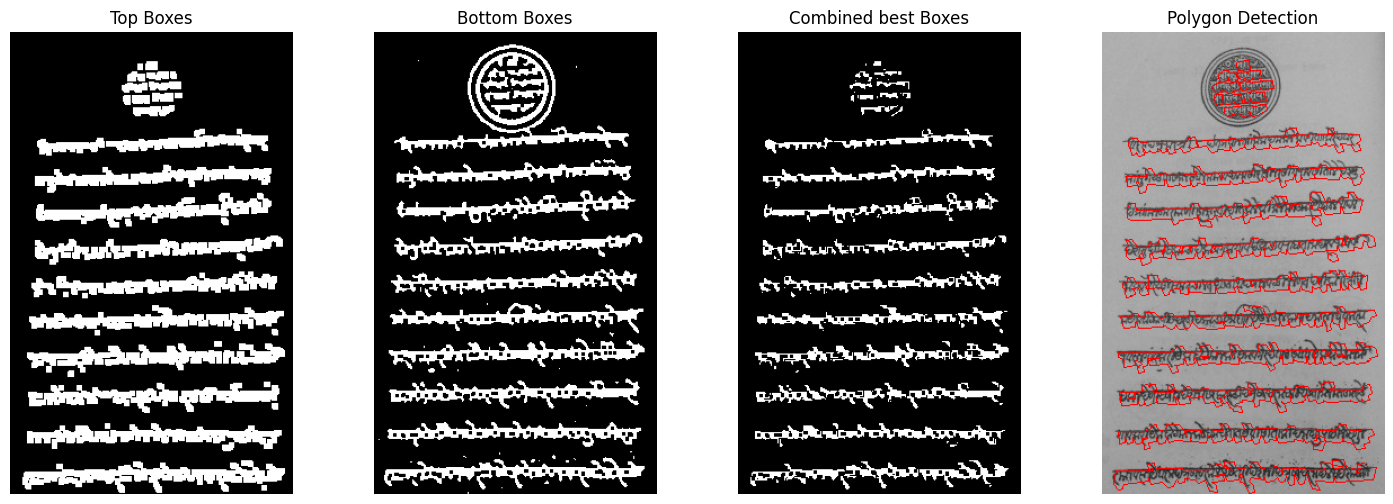

(-0.5, 250.5, 410.5, -0.5)

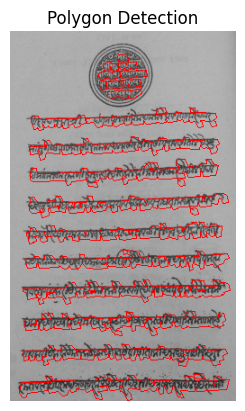

In [403]:

def detect_lines_with_polygons(image, preprocessed):
    """
    Detect text lines using polygonal boundaries
    """
    # Find contours
    preprocessed_gray = cv2.cvtColor(preprocessed, cv2.COLOR_BGR2GRAY)

    # Find contours
    contours, _ = cv2.findContours(
        preprocessed_gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    
    result = image.copy()
    for contour in contours:
        # Filter small contours
        if cv2.contourArea(contour) > 10:  # Adjust threshold as needed
            # Approximate polygon
            epsilon = 0.002 * cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, epsilon, True)
            
            # Draw polygon
            cv2.polylines(result, [approx], True, (0, 0, 255), 2)
    
    return result

import cv2
import numpy as np

def spread_polygon(polygon, spread_distance):
    """
    Spread the polygon outward by a given distance while keeping the same shape.
    :param polygon: The polygon (array of points).
    :param spread_distance: The distance to spread the polygon.
    :return: New polygon with spread vertices.
    """
    # Ensure the polygon is closed
    polygon = polygon.reshape((-1, 2))

    # List to hold the spread points
    spread_polygon = []

    # Iterate through the polygon's points
    for i in range(len(polygon)):
        pt1 = polygon[i]
        pt2 = polygon[(i + 1) % len(polygon)]  # Next point (wrap around to the first)

        # Compute the normal vector (perpendicular to the edge)
        edge = pt2 - pt1
        edge_length = np.linalg.norm(edge)
        
        # Find the unit normal vector
        normal = np.array([-edge[1], edge[0]])  # 90-degree rotation to get normal
        normal = normal / np.linalg.norm(normal)  # Normalize the normal vector
        
        # Move the point outward along the normal vector by the spread distance
        spread_pt = pt1 + normal * spread_distance
        spread_polygon.append(spread_pt)

    return np.array(spread_polygon, dtype=np.int32)

def detect_lines_with_polygons(image, preprocessed):
    """
    Detect text lines using polygonal boundaries and spread the polygons slightly.
    """
    # Convert to grayscale
    preprocessed_gray = cv2.cvtColor(preprocessed, cv2.COLOR_BGR2GRAY)

    # Find contours
    contours, _ = cv2.findContours(
        preprocessed_gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    
    result = image.copy()
    for contour in contours:
        # Filter small contours
        if cv2.contourArea(contour) > 30:  # Adjust threshold as needed
            # Approximate polygon
            epsilon = 0.002 * cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, epsilon, True)
            
            # Spread the polygon
            spread_approx = spread_polygon(approx, spread_distance=1)  # Adjust spread distance as needed
            
            # Draw the spread polygon
            cv2.polylines(result, [spread_approx], True, (0, 0, 255), 1)
    
    return result



BB1=eroded.copy()
BB2=masked_image.copy()
new_image = np.zeros_like(BB1)

# Loop through each row in the image
for y in range(BB1.shape[0]):
    for x in range(BB1.shape[1]):
        # Check pixel height condition (i.e., based on the y-coordinate)
        if BB1[y, x].sum() < 90:  # You can adjust this logic if needed (this is an example)
            new_image[y, x] = BB1[y, x]
        else:
            new_image[y, x] = BB2[y, x]

polygon_result = detect_lines_with_polygons(image_rgb, eroded)

# Create a 1x2 subplot layout
plt.figure(figsize=(18, 6))

# Plot the image with bounding boxes
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(BB1, cv2.COLOR_BGR2RGB))
plt.title('Top Boxes')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(BB2, cv2.COLOR_BGR2RGB))
plt.title('Bottom Boxes')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.title('Combined best Boxes')
plt.axis('off')

# Plot the image with polygon detection
plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(polygon_result, cv2.COLOR_BGR2RGB))
plt.title('Polygon Detection')
plt.axis('off')

plt.show()


plt.imshow(cv2.cvtColor(polygon_result, cv2.COLOR_BGR2RGB))
plt.title('Polygon Detection')
plt.axis('off')

## Below is worst compared to above text segmented image

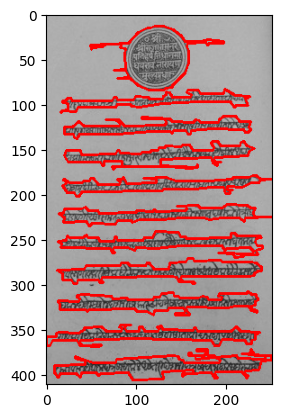

In [402]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_document_image(image):
    """
    Load and display the historical document image with basic information
    """
    # Load the image
    image = cv2.imread(image)
    if image is None:
        raise FileNotFoundError("Image not found")
    
    # Convert BGR to RGB for display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Calculate histogram
    hist_values = []
    colors = ('r','g','b')
    for i, color in enumerate(colors):
        hist = cv2.calcHist([image], [i], None, [256], [0,256])
        hist_values.append(hist)
    
  
    return image

def preprocess_image(image):
    """
    Preprocess the image for text line detection
    """
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur for noise reduction
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Apply adaptive thresholding
    binary = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 11, 2
    )
    
    # Apply morphological operations to connect text components
    kernel = np.ones((3,15), np.uint8)
    morph = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    return morph

def detect_lines_with_bboxes(image, preprocessed):
    """
    Detect text lines and draw bounding boxes
    """
    # Find contours
    contours, _ = cv2.findContours(
        preprocessed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    
    # Sort contours by y-coordinate
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])
    
    # Create copy for visualization
    result = image.copy()
    line_images = []
    
    for i, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        
        # Filter out small contours
        if w > 50 and h > 10 and h<30:  # Adjust these thresholds as needed
            # Draw rectangle
            cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)
            
            # Crop line
            line = image[y:y+h, x:x+w]
            line_images.append(line)
            
            # Save individual line
            cv2.imwrite(f'line_{i+1}.png', line)
    
    return result, line_images

def segment_lines_in_seal(image, preprocessed):
    """
    Detect and segment text lines within the circular seal
    """
    # Detect circles using Hough Circle Transform
    circles = cv2.HoughCircles(
        cv2.cvtColor(image, cv2.COLOR_BGR2GRAY),
        cv2.HOUGH_GRADIENT, 1, 100,
        param1=50, param2=30, minRadius=10, maxRadius=30
    )
    
    result = image.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            # Draw the outer circle
            cv2.circle(result, (i[0], i[1]), i[2], (0, 255, 0), 2)
            
            # Create mask for the circle
            mask = np.zeros_like(preprocessed)
            cv2.circle(mask, (i[0], i[1]), i[2], 255, -1)
            
            # Apply mask to get text within circle
            circle_text = cv2.bitwise_and(preprocessed, mask)
            
            # Find contours within circle
            contours, _ = cv2.findContours(
                circle_text, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            
            # Process each text line within circle
            for j, contour in enumerate(contours):
                x, y, w, h = cv2.boundingRect(contour)
                if w > 20 and h > 5:  # Filter small contours
                    cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 2)
                    line = image[y:y+h, x:x+w]
                    cv2.imwrite(f'circle_line_{j+1}.png', line)
    
    return result

def detect_lines_with_polygons(image, preprocessed):
    """
    Detect text lines using polygonal boundaries
    """
    # Find contours
    contours, _ = cv2.findContours(
        preprocessed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    
    result = image.copy()
    for contour in contours:
        # Filter small contours
        if cv2.contourArea(contour) > 200:  # Adjust threshold as needed
            # Approximate polygon
            epsilon = 0.002 * cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, epsilon, True)
            
            # Draw polygon
            cv2.polylines(result, [approx], True, (0, 0, 255), 2)
    
    return result

# Main processing pipeline
def process_document(image_path):
    """
    Main function to process the document and show all results
    """
    # Load image
    image = load_document_image(image_path)
    
    # Preprocess
    preprocessed = preprocess_image(image)
    
    # Detect lines with bounding boxes
    bbox_result, line_images = detect_lines_with_bboxes(image, preprocessed)
    
    # Segment lines in seal
    seal_result = segment_lines_in_seal(image, preprocessed)
    
    # Detect lines with polygons
    polygon_result = detect_lines_with_polygons(image, preprocessed)
    

    plt.imshow(cv2.cvtColor(polygon_result, cv2.COLOR_BGR2RGB))



image ='./../Dataset/historical-doc.png'
process_document(image)